 Automatically classify waste products using image recognition techniques. <br>
 This project aims to build a model that can differentiate between recyclable and organic waste products using transfer learning

In [1]:
import importlib.util
import sys

packages = {
    "numpy": "numpy==2.2.0",
    "pandas": "pandas==2.2.3",
    "sklearn": "scikit-learn==1.6.0",
    "matplotlib": "matplotlib==3.9.3",
    "tensorflow": "tensorflow==2.18.0",
    "seaborn": "seaborn==0.13.2",
    "pyarrow": "pyarrow",
    "requests": "requests",
}

for module_name, pip_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        !{sys.executable} -m pip install {pip_name}
    else:
        print(f"{module_name} is already installed")

numpy is already installed
pandas is already installed
sklearn is already installed
matplotlib is already installed
tensorflow is already installed
seaborn is already installed
pyarrow is already installed
requests is already installed


Importing required libraries

In [2]:
import numpy as np
import os
# import random, shutil
import glob


from matplotlib import pyplot as plt
from matplotlib import pyplot
from matplotlib.image import imread

# from os import makedirs,listdir
# from shutil import copyfile
# from random import seed
# from random import random

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow.keras.layers import Conv2D, MaxPooling2D,GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import InceptionV3
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')


In [4]:
print(tf.__version__)

2.18.0


I train an algorithm on images and to predict the labels for images in my test set (1 = recyclable, 0 = organic)

In [10]:
import requests
import zipfile
from tqdm import tqdm

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"
file_name = "o-vs-r-split-reduced-1200.zip"

print("Downloading file")
with requests.get(url, stream=True) as response:
    response.raise_for_status()
    with open(file_name, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)


def extract_file_with_progress(file_name):
    print("Extracting file with progress")
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        members = zip_ref.infolist() 
        with tqdm(total=len(members), unit='file') as progress_bar:
            for member in members:
                zip_ref.extract(member)
                progress_bar.update(1)
    print("Finished extracting file")


extract_file_with_progress(file_name)

print("Finished extracting file")
os.remove(file_name)

Extracting file with progress


100%|██████████| 1207/1207 [00:02<00:00, 599.66file/s]

Finished extracting file
Finished extracting file


Model configuration options.

In [11]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2 #  use 20% of the data for validation purposes
verbosity = 1
path = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
labels = ['O', 'R']
seed = 42

Loading images using ImageGeneratorClass

folder:
```python
o-vs-r-split/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R



I create ImageDataGenerators used for training, validation and testing.

Image data generators create batches of tensor image data with real-time data augmentation. The generators loop over the data in batches and are useful in feeding data to the training process.

In [12]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [ ]:
import os

base_dir = os.getcwd()

path = os.path.join(base_dir, "o-vs-r-split", "train")
path_test = os.path.join(base_dir, "o-vs-r-split", "test")

print("Train exists:", os.path.exists(path), path)
print("Test exists:", os.path.exists(path_test), path_test)

In [15]:
train_generator = train_datagen.flow_from_directory(
    directory=path,
    seed=seed,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True,
    target_size=(img_rows, img_cols),
    subset="training"
)

Found 800 images belonging to 2 classes.


In [16]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'validation'
)

Found 200 images belonging to 2 classes.


Create test generator using test_datagen object

In [17]:
test_generator = test_datagen.flow_from_directory(
    directory=path_test,
    class_mode='binary',
    seed=seed,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows, img_cols)
)

Found 200 images belonging to 2 classes.


length of test_generator

In [18]:
print(len(train_generator))

25


Some augmented images

Labels: ['O', 'O', 'O', 'O', 'O']


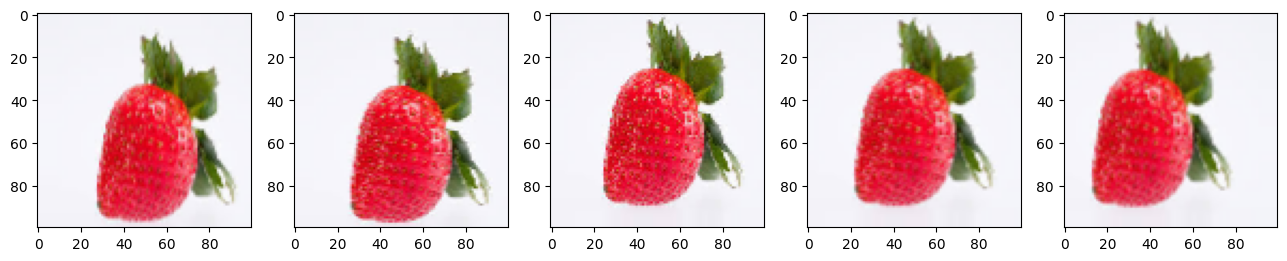

In [19]:
from pathlib import Path

IMG_DIM = (100, 100)

train_files = glob.glob('./o-vs-r-split/train/O/*')
train_files = train_files[:20]
train_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [Path(fn).parent.name for fn in train_files]

img_id = 0
O_generator = train_datagen.flow(train_imgs[img_id:img_id+1], train_labels[img_id:img_id+1],
                                   batch_size=1)
O = [next(O_generator) for i in range(0,5)]
fig, ax = plt.subplots(1,5, figsize=(16, 6))
print('Labels:', [item[1][0] for item in O])
l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]


Load VGG16

In [20]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)



 flatten the output of a vgg model and assign it to the model output, then use a Model object basemodel to group the layers into an object for training and inference.

In [ ]:
output = vgg.layers[-1].output # Take the output tensor of the last layer of the vgg model and store it in output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

In [22]:
# freeze the base model

for layer in basemodel.layers: 
    layer.trainable = False

Create a new model on top.

In [ ]:
input_shape = basemodel.output_shape[1]

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3)) # Dropout layer for regularization
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [24]:
# print summary of the model

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

compile the model using model.compile()

In [25]:
for layer in basemodel.layers: 
    layer.trainable = False

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

I use early stopping to avoid over-training the mode<br>

I define training callbacks. Callbacks are extra instructions that run during training.

In [26]:
from tensorflow.keras.callbacks import LearningRateScheduler


checkpoint_path='O_R_tlearn_vgg16.keras'

# define step decay function
class LossHistory_(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr = []
        
    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(exp_decay(epoch))
        print('lr:', exp_decay(len(self.losses)))

def exp_decay(epoch):
    initial_lrate = 1e-4
    k = 0.1
    lrate = initial_lrate * np.exp(-k*epoch)
    return lrate

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss', 
                    patience = 4, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

fit and train the model

In [27]:
extract_feat_model = model.fit(train_generator, 
                               steps_per_epoch=5, 
                               epochs=10,
                               callbacks = callbacks_list_,   
                               validation_data=val_generator, 
                               validation_steps=val_generator.samples // batch_size, 
                               verbose=1)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5441 - loss: 0.7175lr: 9.048374180359596e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 13s/step - accuracy: 0.5562 - loss: 0.6859 - val_accuracy: 0.5677 - val_loss: 0.6460 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5650 - loss: 0.6764lr: 8.187307530779819e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 53s 12s/step - accuracy: 0.6062 - loss: 0.6516 - val_accuracy: 0.7083 - val_loss: 0.5783 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6825 - loss: 0.5927lr: 7.408182206817179e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 11s/step - accuracy: 0.6625 - loss: 0.6025 - val_accuracy: 0.7240 - val_loss: 0.5344 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7979 - loss: 0.4930lr: 6.703200460356394e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 52s 12s/step - accuracy: 0.7500 - loss: 0.5247 - val_accuracy: 0.8385 - val_loss: 0.4725 - learning_rate: 7.4082e-05
Epoch 5/

plot loss curve for training and validation sets

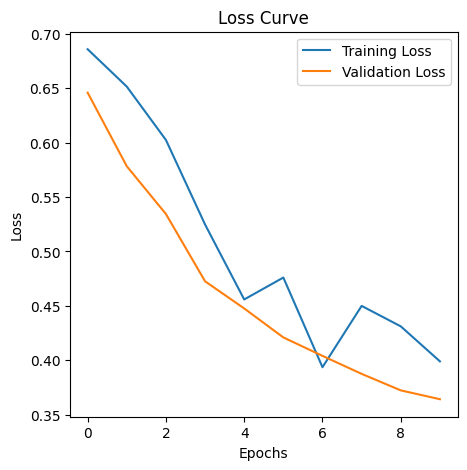

In [28]:
import matplotlib.pyplot as plt

history = extract_feat_model

# plot loss curve
plt.figure(figsize=(5, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Plot accuracy curves for training and validation sets (extract_feat_model)

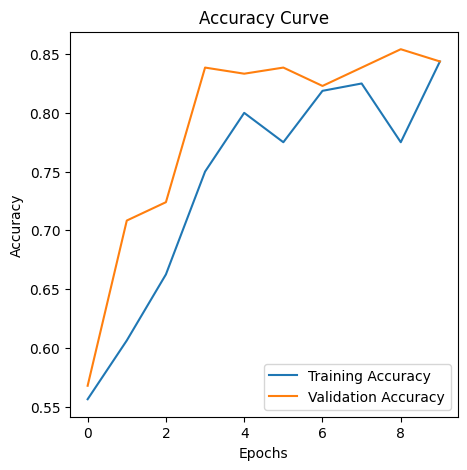

In [29]:
plt.figure(figsize=(5, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()